# Experimento CatBoost

Este notebook reproduce el primer experimento de rangos salariales del microproyecto. Clona la rama `feature/catboost-baseline`, carga los CSV desde Google Drive, ejecuta el pipeline, entrena dos CatBoost y registra una corrida en MLflow local dentro de Colab.

> Para una demostración rápida conserve `FAST_MODE=True`. Para reproducir las cifras oficiales cambie a `False` y use los cuatro CSV completos.

## 1. Configuración de la sesión

In [ ]:
FAST_MODE = False
DATA_MODE = "drive"  # Opciones: "drive", "upload" o "dvc"
DRIVE_DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/MicroProyecto/foorilla"
REPO_URL = "https://github.com/PDS-Microproyecto-Grupo-13/Microproyecto.git"
BRANCH = "feature/catboost-baseline"
RUN_NAME = "colab-catboost-reported-base"

print("Modo rápido:" if FAST_MODE else "Reproducción completa:", FAST_MODE)

Reproducción completa: False


## 2. Clonar el código e instalar dependencias

In [ ]:
import os
from pathlib import Path
import subprocess
import sys

REPO_DIR = Path("/content/Microproyecto")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", BRANCH], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_DIR / "ml/catboost_baseline/requirements.txt")], check=True)
os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))
print("Código listo en", REPO_DIR)

Código listo en /content/Microproyecto


## 3. Acceso a los datos

### Opción recomendada: Google Drive

Monte Drive y ajuste `DRIVE_DATA_DIR` a la carpeta que contiene los cuatro `jobs_*.csv`. Si usa un Shared Drive, la ruta suele comenzar por `/content/drive/Shareddrives/`.

La opción `upload` sirve para una muestra pequeña. La opción `dvc` intentará autenticar el remoto de Google Drive.

In [ ]:
from pathlib import Path

if DATA_MODE == "drive":
    from google.colab import drive

    drive.mount("/content/drive")
    DATA_DIR = Path(DRIVE_DATA_DIR)

elif DATA_MODE == "upload":
    from google.colab import files as colab_files

    upload_dir = Path("/content/uploaded_jobs")
    upload_dir.mkdir(exist_ok=True)

    uploaded = colab_files.upload()

    for name, content in uploaded.items():
        (upload_dir / name).write_bytes(content)

    DATA_DIR = upload_dir

elif DATA_MODE == "dvc":
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "dvc-gdrive"],
        check=True,
    )

    pointers = sorted(
        (REPO_DIR / "data/raw/foorilla").glob("*.csv.dvc")
    )

    subprocess.run(
        ["dvc", "pull", *[str(path) for path in pointers]],
        cwd=REPO_DIR,
        check=True,
    )

    DATA_DIR = REPO_DIR / "data/raw/foorilla"

else:
    raise ValueError("DATA_MODE debe ser drive, upload o dvc")


csv_files = sorted(DATA_DIR.glob("jobs_*.csv"))

assert csv_files, (
    f"No se encontraron jobs_*.csv en {DATA_DIR}. "
    "Ajuste DRIVE_DATA_DIR."
)

[
    (path.name, round(path.stat().st_size / 1_000_000, 2))
    for path in csv_files
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[('jobs_2026-08-16.csv', 395.38),
 ('jobs_2026-08-17.csv', 0.22),
 ('jobs_2026-08-20.csv', 3.63)]

## 4. Importaciones y parámetros del experimento

In [ ]:
import json
from datetime import datetime, timezone

import mlflow
import numpy as np
import pandas as pd
import yaml
from catboost import CatBoostRegressor
from IPython.display import display

from ml.catboost_baseline.data import load_raw_data, prepare_model_data, select_experiment, temporal_split
from ml.catboost_baseline.evaluation import reconstruct_targets, regression_metrics, segment_metrics, training_targets
from ml.catboost_baseline.features import build_features

with (REPO_DIR / "ml/catboost_baseline/params.yaml").open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

MAX_ROWS_PER_FILE = 10_000 if FAST_MODE else None
ITERATIONS = 100 if FAST_MODE else int(config["model"]["iterations"])
print({"max_rows_per_file": MAX_ROWS_PER_FILE, "iterations": ITERATIONS, "experiment": config["data"]["experiment"]})

{'max_rows_per_file': None, 'iterations': 500, 'experiment': 'reported'}


## 5. Carga, deduplicación y controles de calidad

Se verifica esquema, se conserva la versión más reciente de cada ID, se eliminan republicaciones, rangos incompletos/no positivos/desordenados y extremos lejanos.

In [ ]:
raw = load_raw_data(csv_files, max_rows_per_file=MAX_ROWS_PER_FILE)
prepared = prepare_model_data(raw, outlier_iqr_multiplier=float(config["data"]["outlier_iqr_multiplier"]))
display(pd.Series(prepared.audit, name="valor").to_frame())

,valor
source_rows,329290
unique_ids,329062
duplicate_ids_removed,228
unique_vacancies,279889
republications_removed,49173
incomplete_targets,23161
non_positive_targets,5
unordered_targets,11
far_outliers_removed,23
outlier_lower_usd,399.498407


## 6. Muestra reportada y separación temporal

In [ ]:
frame = select_experiment(prepared.frame, config["data"]["experiment"])
split, cutoffs = temporal_split(
    frame,
    train_fraction=float(config["data"]["train_fraction"]),
    validation_fraction=float(config["data"]["validation_fraction"]),
    cutoffs_from=prepared.frame,
)
usable = split.ne("excluded_missing_date")
frame, split = frame.loc[usable].copy(), split.loc[usable]
display(split.value_counts().rename("filas").to_frame())
display(pd.Series(cutoffs, name="fecha").to_frame())

,filas
train,39303
test,7440
validation,6902


,fecha
train_cutoff,2026-03-10T00:00:00+00:00
validation_cutoff,2026-05-25T20:15:05.600000+00:00


## 7. Ingeniería de variables

In [ ]:
features, categorical_features, metadata = build_features(
    frame,
    include_company=bool(config["features"]["include_company"]),
)
print(f"{features.shape[0]:,} filas x {features.shape[1]} variables")
print("Categóricas:", categorical_features)
display(features.head(3))

53,645 filas x 54 variables
Categóricas: ['experience_level', 'work_modality', 'primary_country', 'role_family', 'company']


,experience_level,experience_years,experience_years_missing,work_modality,primary_country,country_count,ambiguous_country,role_family,company_is_agency,publication_year,...,tool_tableau,tool_tensorflow,topic_data_engineering,topic_big_data,topic_finance_fintech,topic_mlops,topic_software_engineering_development,topic_data_science,topic_artificial_intelligence,topic_machine_learning
73069,SE,8.0,0,Remoto,United States,1,0,Data Engineer,0,2026.0,...,0,0,1,1,0,0,0,0,0,0
36015,SE,4.0,0,Presencial,United States,1,0,Data/BI Analyst,0,2026.0,...,0,0,1,1,0,0,0,0,0,0
21053,SE,7.0,0,Presencial,United States,1,0,Data Architect,0,2026.0,...,0,0,1,1,0,0,0,0,0,0


## 8. Entrenamiento de CatBoost

El primer modelo predice `log1p(mínimo)` y el segundo `log1p(amplitud)`. La reconstrucción garantiza `máximo >= mínimo`.

In [ ]:
train_mask = split.eq("train")
validation_mask = split.eq("validation")
test_mask = split.eq("test")
strategy = config["features"]["target_strategy"]

train_first, train_second, target_names = training_targets(
    metadata.loc[train_mask, "y_min_usd"], metadata.loc[train_mask, "y_max_usd"], strategy
)
val_first, val_second, _ = training_targets(
    metadata.loc[validation_mask, "y_min_usd"], metadata.loc[validation_mask, "y_max_usd"], strategy
)

params = dict(config["model"])
params.update(iterations=ITERATIONS, verbose=50)
minimum_model = CatBoostRegressor(**params)
width_model = CatBoostRegressor(**params)

minimum_model.fit(features.loc[train_mask], train_first, cat_features=categorical_features,
                  eval_set=(features.loc[validation_mask], val_first), use_best_model=True)
width_model.fit(features.loc[train_mask], train_second, cat_features=categorical_features,
                eval_set=(features.loc[validation_mask], val_second), use_best_model=True)

0:	learn: 0.3140485	test: 0.3571224	best: 0.3571224 (0)	total: 104ms	remaining: 51.7s
50:	learn: 0.1844556	test: 0.2304729	best: 0.2304729 (50)	total: 3.33s	remaining: 29.3s
100:	learn: 0.1695104	test: 0.2172661	best: 0.2172661 (100)	total: 8.55s	remaining: 33.8s
150:	learn: 0.1627717	test: 0.2121247	best: 0.2121247 (150)	total: 12.8s	remaining: 29.6s
200:	learn: 0.1576268	test: 0.2091636	best: 0.2091636 (200)	total: 16.5s	remaining: 24.5s
250:	learn: 0.1530358	test: 0.2070029	best: 0.2070029 (250)	total: 19.9s	remaining: 19.8s
300:	learn: 0.1491990	test: 0.2050222	best: 0.2050182 (299)	total: 25.7s	remaining: 17s
350:	learn: 0.1458837	test: 0.2032218	best: 0.2032218 (350)	total: 29.3s	remaining: 12.4s
400:	learn: 0.1429953	test: 0.2019365	best: 0.2019365 (400)	total: 32.9s	remaining: 8.12s
450:	learn: 0.1405834	test: 0.2008886	best: 0.2008886 (450)	total: 37.5s	remaining: 4.07s
499:	learn: 0.1380020	test: 0.1995370	best: 0.1995370 (499)	total: 42.2s	remaining: 0us

bestTest = 0.199536

CatBoostRegressor(allow_writing_files=False, depth=8, early_stopping_rounds=50, eval_metric='MAE', iterations=500, l2_leaf_reg=5.0, learning_rate=0.05, loss_function='MAE', random_seed=42, random_strength=1.0, verbose=50)

## 9. Métricas y comparación contra la mediana

In [ ]:
def predict(mask):
    return reconstruct_targets(minimum_model.predict(features.loc[mask]), width_model.predict(features.loc[mask]), strategy)

val_predictions = predict(validation_mask)
test_predictions = predict(test_mask)
val_metrics = regression_metrics(metadata.loc[validation_mask, "y_min_usd"], metadata.loc[validation_mask, "y_max_usd"], *val_predictions)
test_metrics = regression_metrics(metadata.loc[test_mask, "y_min_usd"], metadata.loc[test_mask, "y_max_usd"], *test_predictions)

dummy_min = np.full(test_mask.sum(), metadata.loc[train_mask, "y_min_usd"].median())
dummy_max = np.full(test_mask.sum(), metadata.loc[train_mask, "y_max_usd"].median())
dummy_metrics = regression_metrics(metadata.loc[test_mask, "y_min_usd"], metadata.loc[test_mask, "y_max_usd"], dummy_min, dummy_max)

metrics_table = pd.DataFrame({"CatBoost validación": val_metrics, "CatBoost prueba": test_metrics, "Mediana prueba": dummy_metrics}).T
display(metrics_table.round(3))
improvement = 100 * (dummy_metrics["mae_mean_usd"] - test_metrics["mae_mean_usd"]) / dummy_metrics["mae_mean_usd"]
print(f"Mejora frente a mediana: {improvement:.1f}%")

,mae_y1_usd,mae_y2_usd,mae_mean_usd,rmse_y1_usd,rmse_y2_usd,r2_y1,r2_y2,mae_width_usd,raw_crossing_rate,midpoint_coverage,mean_interval_iou
CatBoost validación,23694.485,32969.861,28332.173,37627.076,54555.149,0.603,0.632,19353.508,0.0,0.619,0.427
CatBoost prueba,27152.038,35668.889,31410.464,44758.161,59124.518,0.471,0.562,20695.334,0.0,0.533,0.375
Mediana prueba,43266.458,65896.866,54581.662,61626.657,89487.497,-0.002,-0.003,35510.106,0.0,0.405,0.255


Mejora frente a mediana: 42.5%


## 10. Importancia de variables y segmentos

In [ ]:
importance = pd.DataFrame({
    "feature": features.columns,
    "minimum": minimum_model.get_feature_importance(),
    "width": width_model.get_feature_importance(),
})
importance["mean"] = importance[["minimum", "width"]].mean(axis=1)
display(importance.nlargest(15, "mean").round(3))

segments = pd.DataFrame(segment_metrics(metadata.loc[test_mask], test_predictions[0], test_predictions[1], minimum_size=100))
display(segments.sort_values("mae_mean_usd", ascending=False).head(15).round(2))

,feature,minimum,width,mean
11,company,27.472,21.827,24.649
1,experience_years,20.246,16.482,18.364
4,primary_country,11.491,14.224,12.857
7,role_family,8.387,7.543,7.965
0,experience_level,7.697,6.669,7.183
10,publication_month,1.518,5.737,3.627
3,work_modality,2.129,3.920,3.024
43,tool_sql,2.084,1.793,1.938
37,tool_python,1.560,1.751,1.655
9,publication_year,1.062,2.120,1.591


,segment,value,rows,mae_y1_usd,mae_y2_usd,mae_mean_usd,mae_width_usd
6,primary_country,India,141,66477.85,77512.92,71995.39,22950.67
2,experience_level,EX,171,31892.61,41571.88,36732.25,26558.87
13,role_family,ML Engineer,446,29549.27,43098.26,36323.76,25075.76
14,role_family,Otra familia,2736,31827.84,39880.24,35854.04,22014.40
8,primary_country,Sin información,124,30741.25,37627.46,34184.35,16408.09
4,experience_level,SE,4706,28518.33,36027.13,32272.73,20522.92
0,target_source,Reportado,7440,27152.04,35668.89,31410.46,20695.33
1,experience_level,EN,337,23632.41,39149.92,31391.16,20926.88
9,primary_country,United States,5929,26070.47,33886.22,29978.35,20725.14
3,experience_level,MI,2216,24295.83,33701.32,28998.57,20515.44


## 11. Registro en MLflow local de Colab

Esta corrida es gratuita y queda en el almacenamiento temporal de Colab. Para conservarla, descargue los artefactos o copie la carpeta a Drive. Para la evidencia de la entrega se debe repetir una corrida en el MLflow de EC2.

In [ ]:
ARTIFACT_DIR = Path("/content/catboost_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)
minimum_model.save_model(ARTIFACT_DIR / f"model_{target_names[0]}.cbm")
width_model.save_model(ARTIFACT_DIR / f"model_{target_names[1]}.cbm")
importance.to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)
metrics_table.to_csv(ARTIFACT_DIR / "metrics.csv")

tracking_uri = "sqlite:////content/mlflow.db"
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("salary-catboost-colab")
with mlflow.start_run(run_name=RUN_NAME) as active_run:
    mlflow.log_params({
        "experiment": config["data"]["experiment"], "iterations": ITERATIONS,
        "include_company": config["features"]["include_company"], "target_strategy": strategy,
        "fast_mode": FAST_MODE, "train_rows": int(train_mask.sum()),
    })
    mlflow.log_metrics({f"validation.{k}": v for k, v in val_metrics.items()})
    mlflow.log_metrics({f"test.{k}": v for k, v in test_metrics.items()})
    mlflow.log_metrics({f"dummy_test.{k}": v for k, v in dummy_metrics.items()})
    mlflow.log_artifacts(str(ARTIFACT_DIR))
    run_id = active_run.info.run_id

print("MLflow URI:", tracking_uri)
print("Run ID:", run_id)

MLflow URI: sqlite:////content/mlflow.db
Run ID: a19176f2d36748fcbf3d02e69330694b


## 12. Matriz compacta de experimentos

Comparamos variantes con los mismos cortes. **La selección debe basarse principalmente en validación**; prueba se conserva como evidencia final.

In [ ]:
dummy_val_min = np.full(validation_mask.sum(), metadata.loc[train_mask, "y_min_usd"].median())
dummy_val_max = np.full(validation_mask.sum(), metadata.loc[train_mask, "y_max_usd"].median())
dummy_val_metrics = regression_metrics(metadata.loc[validation_mask, "y_min_usd"], metadata.loc[validation_mask, "y_max_usd"], dummy_val_min, dummy_val_max)

experiment_results = [
    {"experiment": "Mediana", "validation_mae": dummy_val_metrics["mae_mean_usd"], "test_mae": dummy_metrics["mae_mean_usd"],
     "r2_min": dummy_metrics["r2_y1"], "r2_max": dummy_metrics["r2_y2"], "coverage": dummy_metrics["midpoint_coverage"], "iou": dummy_metrics["mean_interval_iou"], "run_id": None},
    {"experiment": "CatBoost empresa + amplitud", "validation_mae": val_metrics["mae_mean_usd"], "test_mae": test_metrics["mae_mean_usd"],
     "r2_min": test_metrics["r2_y1"], "r2_max": test_metrics["r2_y2"], "coverage": test_metrics["midpoint_coverage"], "iou": test_metrics["mean_interval_iou"], "run_id": run_id},
]
predictions_by_experiment = {"CatBoost empresa + amplitud": test_predictions}

def train_variant(label, include_company, target_strategy):
    vf, vc, vm = build_features(frame, include_company=include_company)
    y1, y2, names = training_targets(vm.loc[train_mask, "y_min_usd"], vm.loc[train_mask, "y_max_usd"], target_strategy)
    v1, v2, _ = training_targets(vm.loc[validation_mask, "y_min_usd"], vm.loc[validation_mask, "y_max_usd"], target_strategy)
    p = dict(config["model"]); p.update(iterations=ITERATIONS, verbose=50)
    m1, m2 = CatBoostRegressor(**p), CatBoostRegressor(**p)
    m1.fit(vf.loc[train_mask], y1, cat_features=vc, eval_set=(vf.loc[validation_mask], v1), use_best_model=True)
    m2.fit(vf.loc[train_mask], y2, cat_features=vc, eval_set=(vf.loc[validation_mask], v2), use_best_model=True)
    vp = reconstruct_targets(m1.predict(vf.loc[validation_mask]), m2.predict(vf.loc[validation_mask]), target_strategy)
    tp = reconstruct_targets(m1.predict(vf.loc[test_mask]), m2.predict(vf.loc[test_mask]), target_strategy)
    vmet = regression_metrics(vm.loc[validation_mask, "y_min_usd"], vm.loc[validation_mask, "y_max_usd"], *vp)
    tmet = regression_metrics(vm.loc[test_mask, "y_min_usd"], vm.loc[test_mask, "y_max_usd"], *tp)
    out = Path("/content/variant_artifacts") / label.lower().replace(" ", "_").replace("+", "plus")
    out.mkdir(parents=True, exist_ok=True)
    m1.save_model(out / f"model_{names[0]}.cbm"); m2.save_model(out / f"model_{names[1]}.cbm")
    with mlflow.start_run(run_name=label) as vr:
        mlflow.log_params({"include_company": include_company, "target_strategy": target_strategy, "iterations": ITERATIONS, "fast_mode": FAST_MODE})
        mlflow.log_metrics({f"validation.{k}": value for k, value in vmet.items()})
        mlflow.log_metrics({f"test.{k}": value for k, value in tmet.items()})
        mlflow.log_artifacts(str(out))
        variant_run_id = vr.info.run_id
    result = {"experiment": label, "validation_mae": vmet["mae_mean_usd"], "test_mae": tmet["mae_mean_usd"],
              "r2_min": tmet["r2_y1"], "r2_max": tmet["r2_y2"], "coverage": tmet["midpoint_coverage"],
              "iou": tmet["mean_interval_iou"], "run_id": variant_run_id}
    return result, tp


In [ ]:
variants = [
    ("CatBoost sin empresa + amplitud", False, "minimum_width_log"),
    ("CatBoost empresa + directo", True, "direct"),
]
for label, include_company, target_strategy in variants:
    result, predictions = train_variant(label, include_company, target_strategy)
    experiment_results.append(result)
    predictions_by_experiment[label] = predictions

experiment_table = pd.DataFrame(experiment_results)
display(experiment_table.round(3))


0:	learn: 0.3176416	test: 0.3627796	best: 0.3627796 (0)	total: 72.6ms	remaining: 36.2s
50:	learn: 0.2259819	test: 0.2729148	best: 0.2729148 (50)	total: 3.09s	remaining: 27.2s
100:	learn: 0.2117498	test: 0.2638105	best: 0.2638105 (100)	total: 6.41s	remaining: 25.3s
150:	learn: 0.2039669	test: 0.2599813	best: 0.2599813 (150)	total: 11.6s	remaining: 26.7s
200:	learn: 0.1980628	test: 0.2567386	best: 0.2567386 (200)	total: 14.7s	remaining: 21.9s
250:	learn: 0.1930921	test: 0.2548550	best: 0.2548550 (250)	total: 17.9s	remaining: 17.8s
300:	learn: 0.1885835	test: 0.2532520	best: 0.2531618 (295)	total: 21.4s	remaining: 14.1s
350:	learn: 0.1850496	test: 0.2519753	best: 0.2519741 (349)	total: 26.7s	remaining: 11.3s
400:	learn: 0.1821221	test: 0.2513581	best: 0.2513490 (396)	total: 29.8s	remaining: 7.35s
450:	learn: 0.1795955	test: 0.2504622	best: 0.2504622 (450)	total: 32.8s	remaining: 3.57s
499:	learn: 0.1773518	test: 0.2499843	best: 0.2499076 (498)	total: 35.9s	remaining: 0us

bestTest = 0.249

,experiment,validation_mae,test_mae,r2_min,r2_max,coverage,iou,run_id
0,Mediana,56083.455,54581.662,-0.002,-0.003,0.405,0.255,None
1,CatBoost empresa + amplitud,28332.173,31410.464,0.471,0.562,0.533,0.375,a19176f2d36748fcbf3d02e69330694b
2,CatBoost sin empresa + amplitud,36552.443,38069.416,0.329,0.392,0.513,0.327,bd0d9304920b44d396fdbeff8d5ecaa4
3,CatBoost empresa + directo,28279.556,30776.996,0.471,0.586,0.565,0.385,6606e346d393412aae8d62c240396bdb


## 13. Visualizaciones de desempeño

Las figuras se guardan en `/content/experiment_plots` y se anexan como artefactos a la corrida base de MLflow.

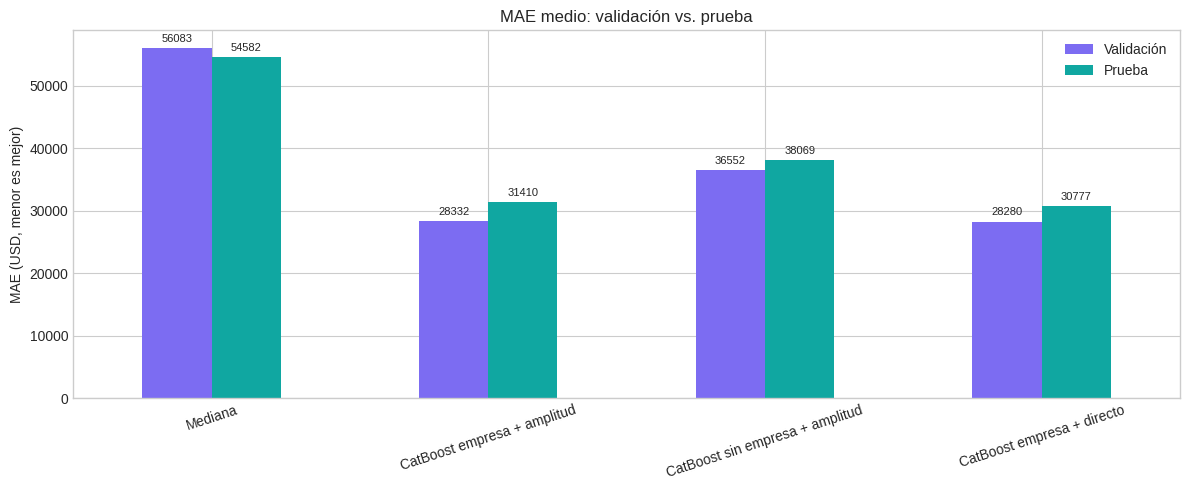

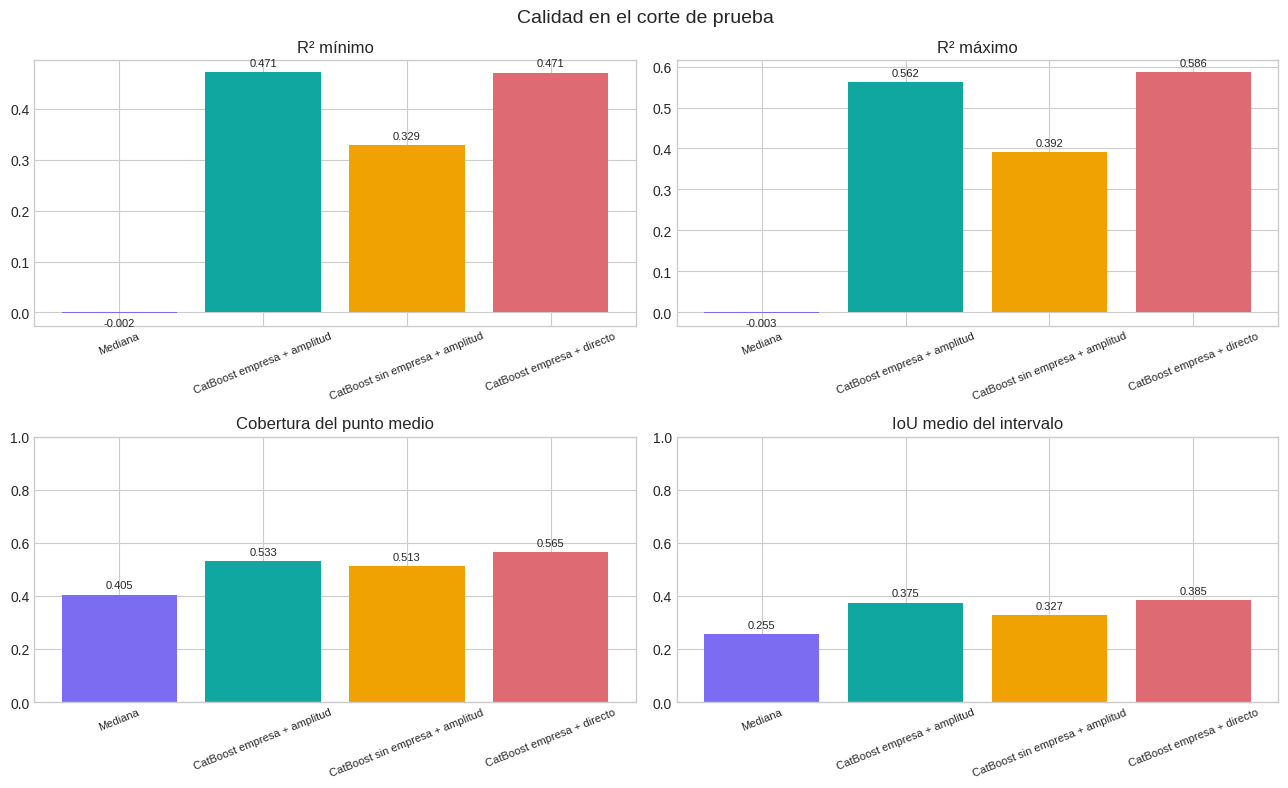

In [ ]:
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
PLOT_DIR = Path("/content/experiment_plots"); PLOT_DIR.mkdir(exist_ok=True)
COLORS = ["#7c6cf2", "#10a7a1", "#f0a202", "#de6a73"]

ax = experiment_table.set_index("experiment")[["validation_mae", "test_mae"]].plot(
    kind="bar", figsize=(12, 5), color=["#7c6cf2", "#10a7a1"])
ax.set(title="MAE medio: validación vs. prueba", ylabel="MAE (USD, menor es mejor)", xlabel="")
ax.tick_params(axis="x", rotation=18); ax.legend(["Validación", "Prueba"])
for container in ax.containers: ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR / "01_mae_comparison.png", dpi=160, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (column, title, limits) in zip(axes.flat, [
    ("r2_min", "R² mínimo", None), ("r2_max", "R² máximo", None),
    ("coverage", "Cobertura del punto medio", (0, 1)), ("iou", "IoU medio del intervalo", (0, 1))]):
    bars = ax.bar(experiment_table["experiment"], experiment_table[column], color=COLORS)
    ax.set_title(title); ax.tick_params(axis="x", rotation=22, labelsize=8); ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    if limits: ax.set_ylim(*limits)
fig.suptitle("Calidad en el corte de prueba", fontsize=14)
plt.tight_layout(); plt.savefig(PLOT_DIR / "02_quality_metrics.png", dpi=160, bbox_inches="tight"); plt.show()


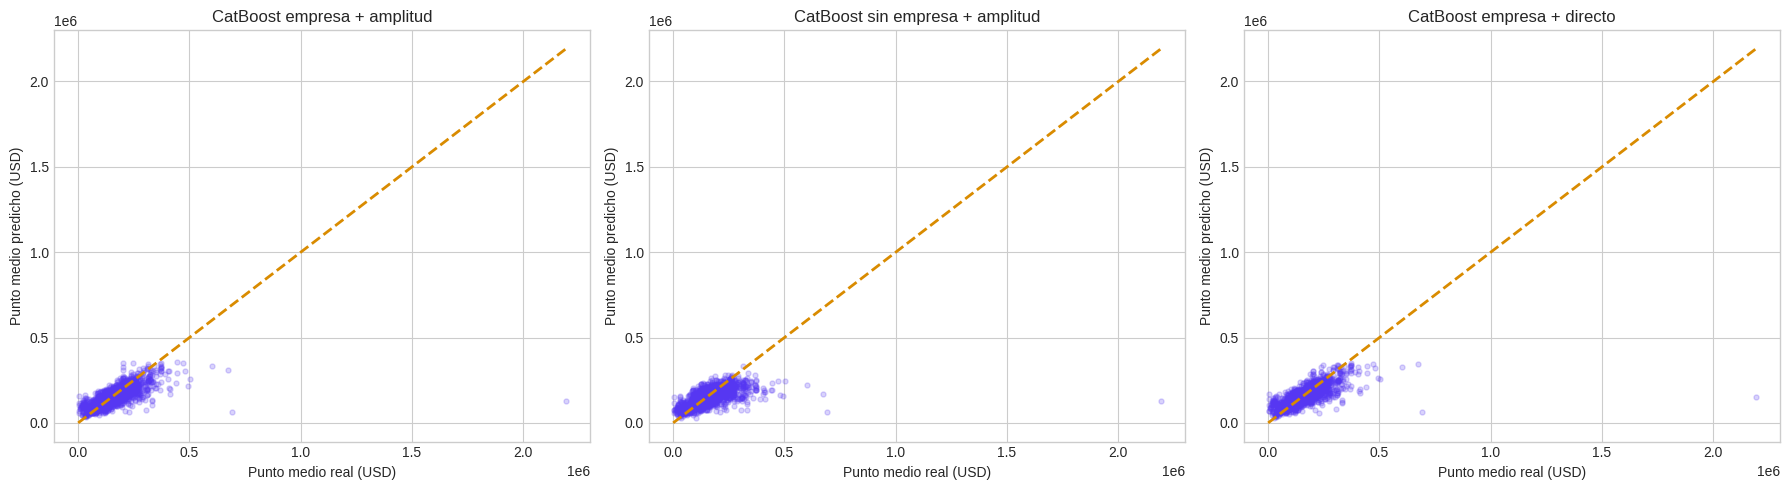

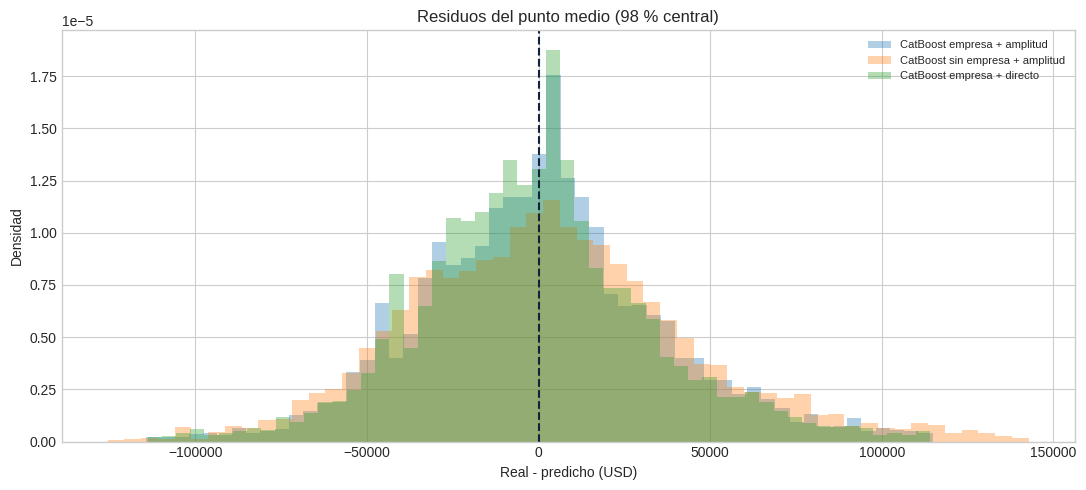

In [ ]:
actual_midpoint = ((metadata.loc[test_mask, "y_min_usd"] + metadata.loc[test_mask, "y_max_usd"]) / 2).to_numpy()
rng = np.random.default_rng(42); sample = rng.choice(len(actual_midpoint), size=min(2500, len(actual_midpoint)), replace=False)
names = list(predictions_by_experiment)
fig, axes = plt.subplots(1, len(names), figsize=(6 * len(names), 5), squeeze=False)
for ax, name in zip(axes.flat, names):
    pred = predictions_by_experiment[name]; predicted_midpoint = (pred[0] + pred[1]) / 2
    upper = max(actual_midpoint[sample].max(), predicted_midpoint[sample].max())
    ax.scatter(actual_midpoint[sample], predicted_midpoint[sample], alpha=.22, s=13, color="#5637f2")
    ax.plot([0, upper], [0, upper], "--", color="#d98b00", linewidth=2)
    ax.set(title=name, xlabel="Punto medio real (USD)", ylabel="Punto medio predicho (USD)")
plt.tight_layout(); plt.savefig(PLOT_DIR / "03_actual_vs_predicted.png", dpi=160, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for name, pred in predictions_by_experiment.items():
    residuals = actual_midpoint - (pred[0] + pred[1]) / 2
    central = residuals[np.abs(residuals) <= np.quantile(np.abs(residuals), .98)]
    ax.hist(central, bins=55, alpha=.35, density=True, label=name)
ax.axvline(0, color="#14213d", linestyle="--")
ax.set(title="Residuos del punto medio (98 % central)", xlabel="Real - predicho (USD)", ylabel="Densidad")
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig(PLOT_DIR / "04_residuals.png", dpi=160, bbox_inches="tight"); plt.show()


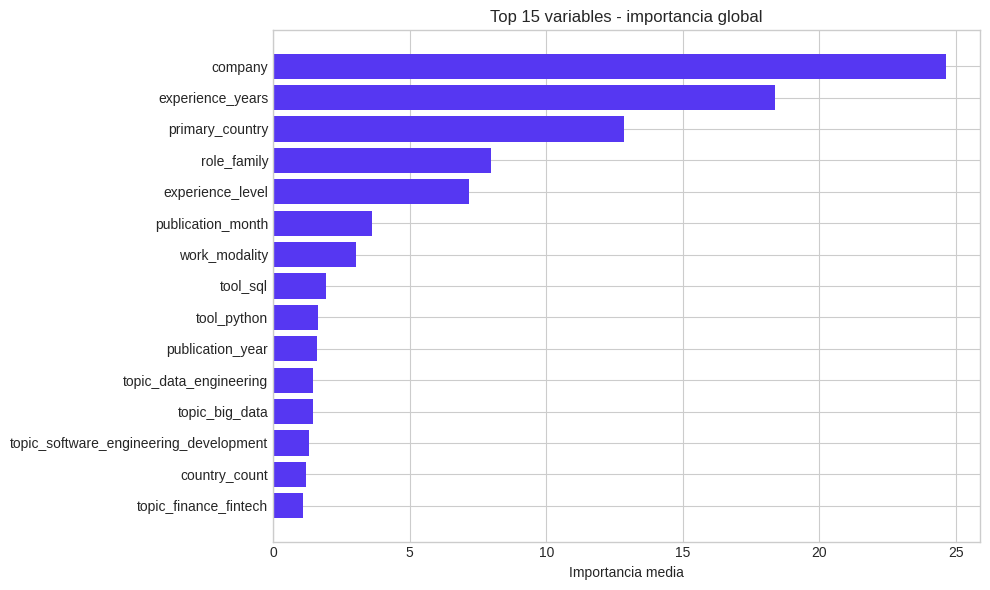

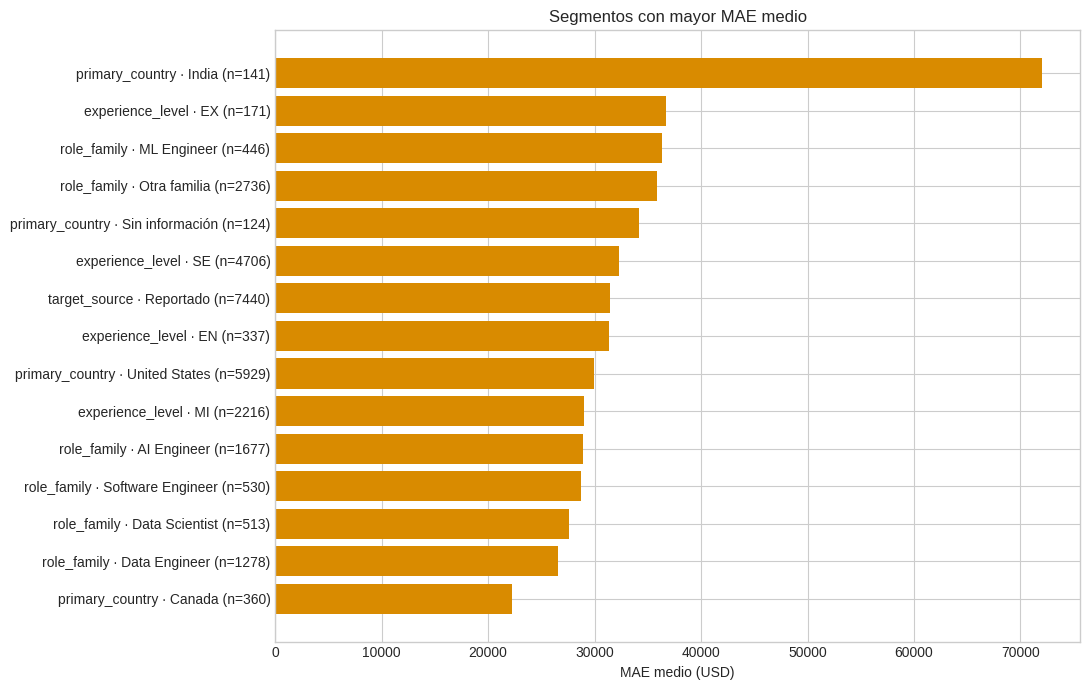

Se registraron seis gráficas en la corrida base: a19176f2d36748fcbf3d02e69330694b


In [ ]:
top = importance.nlargest(15, "mean").sort_values("mean")
fig, ax = plt.subplots(figsize=(10, 6)); ax.barh(top["feature"], top["mean"], color="#5637f2")
ax.set(title="Top 15 variables - importancia global", xlabel="Importancia media")
plt.tight_layout(); plt.savefig(PLOT_DIR / "05_feature_importance.png", dpi=160, bbox_inches="tight"); plt.show()

sp = segments.nlargest(15, "mae_mean_usd").sort_values("mae_mean_usd")
labels = sp["segment"] + " · " + sp["value"] + " (n=" + sp["rows"].astype(str) + ")"
fig, ax = plt.subplots(figsize=(11, 7)); ax.barh(labels, sp["mae_mean_usd"], color="#d98b00")
ax.set(title="Segmentos con mayor MAE medio", xlabel="MAE medio (USD)")
plt.tight_layout(); plt.savefig(PLOT_DIR / "06_segment_errors.png", dpi=160, bbox_inches="tight"); plt.show()

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifacts(str(PLOT_DIR), artifact_path="plots")
print("Se registraron seis gráficas en la corrida base:", run_id)


,tags.mlflow.runName,status,metrics.validation.mae_mean_usd,metrics.test.mae_mean_usd,metrics.test.r2_y1,metrics.test.r2_y2
0,CatBoost empresa + directo,FINISHED,28279.556,30776.996,0.471,0.586
2,colab-catboost-reported-base,FINISHED,28332.173,31410.464,0.471,0.562
5,colab-catboost-reported-base,FINISHED,33077.341,31087.923,0.541,0.563
3,CatBoost empresa + directo,FINISHED,34267.241,32487.097,0.537,0.541
1,CatBoost sin empresa + amplitud,FINISHED,36552.443,38069.416,0.329,0.392
4,CatBoost sin empresa + amplitud,FINISHED,39291.650,36975.553,0.434,0.396


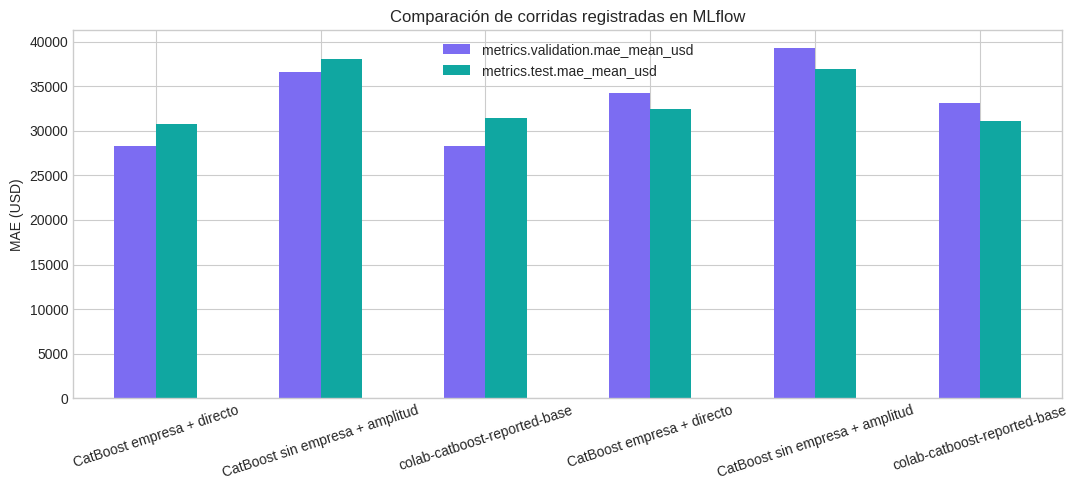

In [ ]:
runs = mlflow.search_runs(experiment_names=["salary-catboost-colab"])
columns = ["tags.mlflow.runName", "status", "metrics.validation.mae_mean_usd",
           "metrics.test.mae_mean_usd", "metrics.test.r2_y1", "metrics.test.r2_y2"]
run_comparison = runs[[column for column in columns if column in runs]]
display(run_comparison.sort_values("metrics.validation.mae_mean_usd").round(3))

chart = run_comparison.dropna(subset=["metrics.validation.mae_mean_usd"]).set_index("tags.mlflow.runName")
ax = chart[["metrics.validation.mae_mean_usd", "metrics.test.mae_mean_usd"]].plot.bar(
    figsize=(11, 5), color=["#7c6cf2", "#10a7a1"])
ax.set(title="Comparación de corridas registradas en MLflow", ylabel="MAE (USD)", xlabel="")
ax.tick_params(axis="x", rotation=18); plt.tight_layout(); plt.show()


## 14. Consultar las corridas

In [ ]:
runs = mlflow.search_runs(experiment_names=["salary-catboost-colab"])
display(runs[["tags.mlflow.runName", "status", "metrics.test.mae_mean_usd", "metrics.test.r2_y1", "metrics.test.r2_y2"]])

,tags.mlflow.runName,status,metrics.test.mae_mean_usd,metrics.test.r2_y1,metrics.test.r2_y2
0,CatBoost empresa + directo,FINISHED,30776.996096,0.471065,0.585991
1,CatBoost sin empresa + amplitud,FINISHED,38069.415951,0.329334,0.391736
2,colab-catboost-reported-base,FINISHED,31410.463669,0.471457,0.562042
3,CatBoost empresa + directo,FINISHED,32487.096932,0.537286,0.540531
4,CatBoost sin empresa + amplitud,FINISHED,36975.553295,0.434334,0.395717
5,colab-catboost-reported-base,FINISHED,31087.922639,0.541185,0.562634


## 15. Ejemplo de salida que consumirá el frontend

In [ ]:
example_index = metadata.loc[test_mask].index[0]
actual = metadata.loc[example_index]
position = list(metadata.loc[test_mask].index).index(example_index)
response = {
    "currency": "USD", "period": "year",
    "salary_min": round(float(test_predictions[0][position]), 2),
    "salary_max": round(float(test_predictions[1][position]), 2),
    "salary_midpoint": round(float((test_predictions[0][position] + test_predictions[1][position]) / 2), 2),
    "model_name": "catboost-reported-baseline", "run_id": run_id,
}
print(json.dumps(response, indent=2, ensure_ascii=False))
print("Valores reales reservados:", actual[["y_min_usd", "y_max_usd"]].to_dict())

{
  "currency": "USD",
  "period": "year",
  "salary_min": 97245.22,
  "salary_max": 124487.24,
  "salary_midpoint": 110866.23,
  "model_name": "catboost-reported-baseline",
  "run_id": "a19176f2d36748fcbf3d02e69330694b"
}
Valores reales reservados: {'y_min_usd': 125000.0, 'y_max_usd': 165000.0}


In [ ]:
# ============================================================
# EXPERIMENTO B
# Train: salarios Reportados
# Evaluación externa: salarios Estimados por Foorilla
# Objetivo: medir alineamiento, NO accuracy contra ground truth
# ============================================================

alignment_frame = prepared.frame.loc[
    prepared.frame["target_source"].isin(["Reportado", "Estimado"])
].copy()

print("Distribución del Experimento B:")
display(
    alignment_frame["target_source"]
    .value_counts()
    .rename("filas")
    .to_frame()
)


def run_experiment_b(label, include_company):
    # Construimos las mismas features para Reportados y Estimados
    features_b, categorical_b, metadata_b = build_features(
        alignment_frame,
        include_company=include_company,
    )

    train_b = metadata_b["target_source"].eq("Reportado")
    estimated_b = metadata_b["target_source"].eq("Estimado")

    # Para aislar el efecto de company usamos la misma estrategia
    # en ambos experimentos: predicción directa mínimo / máximo.
    strategy_b = "direct"

    train_min, train_max, _ = training_targets(
        metadata_b.loc[train_b, "y_min_usd"],
        metadata_b.loc[train_b, "y_max_usd"],
        strategy_b,
    )

    # Configuración completa de CatBoost
    params_b = dict(config["model"])
    params_b.update(
        iterations=int(config["model"]["iterations"]),
        verbose=100,
    )

    # MUY IMPORTANTE:
    # No usamos los Estimados para early stopping.
    # Así evitamos afinar el modelo hacia Foorilla.
    params_b.pop("early_stopping_rounds", None)

    model_min_b = CatBoostRegressor(**params_b)
    model_max_b = CatBoostRegressor(**params_b)

    print(f"\nEntrenando: {label}")

    model_min_b.fit(
        features_b.loc[train_b],
        train_min,
        cat_features=categorical_b,
    )

    model_max_b.fit(
        features_b.loc[train_b],
        train_max,
        cat_features=categorical_b,
    )

    # Predicción sobre los salarios ESTIMADOS
    predictions_b = reconstruct_targets(
        model_min_b.predict(features_b.loc[estimated_b]),
        model_max_b.predict(features_b.loc[estimated_b]),
        strategy_b,
    )

    metrics_b = regression_metrics(
        metadata_b.loc[estimated_b, "y_min_usd"],
        metadata_b.loc[estimated_b, "y_max_usd"],
        *predictions_b,
    )

    result = {
        "experiment": label,
        "train_rows": int(train_b.sum()),
        "evaluation_rows": int(estimated_b.sum()),
        **metrics_b,
    }

    return {
        "result": result,
        "features": features_b,
        "metadata": metadata_b,
        "train_mask": train_b,
        "estimated_mask": estimated_b,
        "predictions": predictions_b,
        "model_min": model_min_b,
        "model_max": model_max_b,
    }


# ------------------------------------------------------------
# 1. CatBoost DIRECTO con empresa
# ------------------------------------------------------------

experiment_b_company = run_experiment_b(
    label="B - Reportado → Estimado | con empresa",
    include_company=True,
)


# ------------------------------------------------------------
# 2. CatBoost DIRECTO sin empresa
# ------------------------------------------------------------

experiment_b_no_company = run_experiment_b(
    label="B - Reportado → Estimado | sin empresa",
    include_company=False,
)


# ------------------------------------------------------------
# 3. Baseline: mediana de los salarios REPORTADOS
# aplicada sobre los ESTIMADOS
# ------------------------------------------------------------

metadata_b = experiment_b_company["metadata"]
train_b = experiment_b_company["train_mask"]
estimated_b = experiment_b_company["estimated_mask"]

dummy_min_b = np.full(
    estimated_b.sum(),
    metadata_b.loc[train_b, "y_min_usd"].median(),
)

dummy_max_b = np.full(
    estimated_b.sum(),
    metadata_b.loc[train_b, "y_max_usd"].median(),
)

dummy_metrics_b = regression_metrics(
    metadata_b.loc[estimated_b, "y_min_usd"],
    metadata_b.loc[estimated_b, "y_max_usd"],
    dummy_min_b,
    dummy_max_b,
)

baseline_b = {
    "experiment": "B - Mediana Reportados → Estimados",
    "train_rows": int(train_b.sum()),
    "evaluation_rows": int(estimated_b.sum()),
    **dummy_metrics_b,
}


# ------------------------------------------------------------
# Tabla final del Experimento B
# ------------------------------------------------------------

experiment_b_table = pd.DataFrame(
    [
        baseline_b,
        experiment_b_company["result"],
        experiment_b_no_company["result"],
    ]
)

columns_b = [
    "experiment",
    "train_rows",
    "evaluation_rows",
    "mae_y1_usd",
    "mae_y2_usd",
    "mae_mean_usd",
    "rmse_y1_usd",
    "rmse_y2_usd",
    "r2_y1",
    "r2_y2",
    "mae_width_usd",
    "raw_crossing_rate",
    "midpoint_coverage",
    "mean_interval_iou",
]

display(
    experiment_b_table[columns_b]
    .sort_values("mae_mean_usd")
    .round(3)
)

Distribución del Experimento B:


,filas
target_source,
Estimado,198229
Reportado,53645



Entrenando: B - Reportado → Estimado | con empresa
0:	learn: 39725.5621022	total: 226ms	remaining: 1m 52s
100:	learn: 21778.7982772	total: 10.4s	remaining: 41.1s
200:	learn: 20362.0888322	total: 20s	remaining: 29.7s
300:	learn: 19384.0927401	total: 31s	remaining: 20.5s
400:	learn: 18668.7606680	total: 41.8s	remaining: 10.3s
499:	learn: 18112.5709942	total: 50.9s	remaining: 0us
0:	learn: 59272.2632568	total: 102ms	remaining: 51.1s
100:	learn: 31273.6203219	total: 10.3s	remaining: 40.6s
200:	learn: 29276.3301166	total: 21.3s	remaining: 31.6s
300:	learn: 28010.9505361	total: 30s	remaining: 19.8s
400:	learn: 27159.9599615	total: 41.5s	remaining: 10.2s
499:	learn: 26511.1006730	total: 52.4s	remaining: 0us

Entrenando: B - Reportado → Estimado | sin empresa
0:	learn: 40157.6592006	total: 87.5ms	remaining: 43.7s
100:	learn: 27798.0488271	total: 9.1s	remaining: 35.9s
200:	learn: 26287.0668952	total: 18.2s	remaining: 27.1s
300:	learn: 25265.7705780	total: 28.4s	remaining: 18.8s
400:	learn: 245

,experiment,train_rows,evaluation_rows,mae_y1_usd,mae_y2_usd,mae_mean_usd,rmse_y1_usd,rmse_y2_usd,r2_y1,r2_y2,mae_width_usd,raw_crossing_rate,midpoint_coverage,mean_interval_iou
2,B - Reportado → Estimado | sin empresa,53645,198229,30354.446,46099.885,38227.165,37182.025,57600.138,0.375,0.421,22513.153,0.041,0.242,0.166
1,B - Reportado → Estimado | con empresa,53645,198229,30412.854,47197.216,38805.035,37563.724,59921.485,0.362,0.373,25429.131,0.056,0.218,0.154
0,B - Mediana Reportados → Estimados,53645,198229,75742.182,114709.375,95225.778,84863.125,128544.956,-2.254,-1.884,43069.806,0.000,0.175,0.117


In [ ]:
# ============================================================
# DIAGNÓSTICO B:
# Empresas conocidas vs empresas nunca vistas
# ============================================================

metadata_b = experiment_b_company["metadata"]
estimated_mask_b = experiment_b_company["estimated_mask"]
train_mask_b = experiment_b_company["train_mask"]

company_series = (
    alignment_frame["company"]
    .fillna("Sin información")
    .astype(str)
)

known_companies = set(
    company_series.loc[train_mask_b]
)

estimated_companies = company_series.loc[estimated_mask_b]

seen_company_mask = estimated_companies.isin(known_companies)
unseen_company_mask = ~seen_company_mask


print("Empresas en evaluación:")
print(
    {
        "estimados_total": int(len(estimated_companies)),
        "empresa_vista_en_reportados": int(seen_company_mask.sum()),
        "empresa_nunca_vista": int(unseen_company_mask.sum()),
        "porcentaje_nueva_empresa": round(
            100 * unseen_company_mask.mean(), 2
        ),
    }
)


def metrics_for_subset(experiment, subset_mask):
    preds = experiment["predictions"]

    # subset_mask corresponde al orden del conjunto Estimado
    positions = np.flatnonzero(subset_mask.to_numpy())

    actual_metadata = experiment["metadata"].loc[
        experiment["estimated_mask"]
    ].iloc[positions]

    return regression_metrics(
        actual_metadata["y_min_usd"].to_numpy(),
        actual_metadata["y_max_usd"].to_numpy(),
        preds[0][positions],
        preds[1][positions],
        preds[2][positions],
        preds[3][positions],
    )


diagnostic_rows = []

for model_label, experiment in [
    ("Con empresa", experiment_b_company),
    ("Sin empresa", experiment_b_no_company),
]:
    for segment_label, mask in [
        ("Empresa conocida", seen_company_mask),
        ("Empresa nueva", unseen_company_mask),
    ]:
        metrics = metrics_for_subset(experiment, mask)

        diagnostic_rows.append(
            {
                "modelo": model_label,
                "segmento": segment_label,
                "filas": int(mask.sum()),
                **metrics,
            }
        )


company_generalization_table = pd.DataFrame(diagnostic_rows)

display(
    company_generalization_table[
        [
            "modelo",
            "segmento",
            "filas",
            "mae_mean_usd",
            "r2_y1",
            "r2_y2",
            "midpoint_coverage",
            "mean_interval_iou",
        ]
    ].round(3)
)

Empresas en evaluación:
{'estimados_total': 198229, 'empresa_vista_en_reportados': 119309, 'empresa_nunca_vista': 78920, 'porcentaje_nueva_empresa': np.float64(39.81)}


,modelo,segmento,filas,mae_mean_usd,r2_y1,r2_y2,midpoint_coverage,mean_interval_iou
0,Con empresa,Empresa conocida,119309,41569.716,0.306,0.274,0.209,0.141
1,Con empresa,Empresa nueva,78920,34625.470,0.403,0.482,0.233,0.174
2,Sin empresa,Empresa conocida,119309,39032.560,0.359,0.393,0.213,0.145
3,Sin empresa,Empresa nueva,78920,37009.593,0.357,0.428,0.286,0.198


In [ ]:
# ============================================================
# EXPERIMENTO B.1
# Distribution Shift: Reportado vs Estimado
#
# Objetivo:
# determinar si las diferencias observadas en el Experimento B
# se explican por:
#
# A) poblaciones laborales diferentes
# B) niveles salariales diferentes
# C) ambas cosas
#
# NO entrena ningún modelo.
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Construir exactamente las mismas features del modelo
# ------------------------------------------------------------

features_b1, _, metadata_b1 = build_features(
    alignment_frame,
    include_company=False,
)

b1 = pd.DataFrame(index=alignment_frame.index)

b1["target_source"] = metadata_b1["target_source"]
b1["published"] = metadata_b1["published"]

# Targets
b1["y_min_usd"] = metadata_b1["y_min_usd"]
b1["y_max_usd"] = metadata_b1["y_max_usd"]

b1["salary_midpoint_usd"] = (
    b1["y_min_usd"] + b1["y_max_usd"]
) / 2

b1["salary_width_usd"] = (
    b1["y_max_usd"] - b1["y_min_usd"]
)

# Features estructurales que queremos comparar
analysis_features = [
    "experience_years",
    "experience_level",
    "work_modality",
    "primary_country",
    "role_family",
    "company_is_agency",
]

for column in analysis_features:
    b1[column] = features_b1[column]

# Solo Reportado y Estimado
b1 = b1[
    b1["target_source"].isin(["Reportado", "Estimado"])
].copy()

print("Filas analizadas:")
display(
    b1["target_source"]
    .value_counts()
    .rename("filas")
    .to_frame()
)


# ============================================================
# 2. DISTRIBUCIÓN SALARIAL
# ============================================================

numeric_columns = [
    "y_min_usd",
    "y_max_usd",
    "salary_midpoint_usd",
    "salary_width_usd",
    "experience_years",
]

numeric_rows = []

for source in ["Reportado", "Estimado"]:

    subset = b1.loc[b1["target_source"].eq(source)]

    for column in numeric_columns:

        values = pd.to_numeric(
            subset[column],
            errors="coerce",
        ).dropna()

        numeric_rows.append(
            {
                "target_source": source,
                "variable": column,
                "n": len(values),
                "mean": values.mean(),
                "p25": values.quantile(0.25),
                "median": values.median(),
                "p75": values.quantile(0.75),
                "std": values.std(),
            }
        )

numeric_summary_b1 = pd.DataFrame(numeric_rows)

print("\n=== Distribuciones numéricas ===")

display(
    numeric_summary_b1.round(2)
)


# ============================================================
# 3. COMPARACIÓN DIRECTA DE MEDIANAS
# ============================================================

median_comparison = (
    numeric_summary_b1
    .pivot(
        index="variable",
        columns="target_source",
        values="median",
    )
    .reset_index()
)

median_comparison["difference_usd_or_units"] = (
    median_comparison["Estimado"]
    - median_comparison["Reportado"]
)

median_comparison["ratio_estimado_reportado"] = (
    median_comparison["Estimado"]
    / median_comparison["Reportado"]
)

print("\n=== Diferencia de medianas ===")

display(
    median_comparison.round(3)
)


# ============================================================
# 4. STANDARDIZED MEAN DIFFERENCE
#
# |SMD|:
# < 0.10  → muy similar
# 0.10-0.20 → diferencia pequeña
# 0.20-0.50 → diferencia moderada
# > 0.50 → diferencia fuerte
# ============================================================

smd_rows = []

for column in numeric_columns:

    reported = pd.to_numeric(
        b1.loc[
            b1["target_source"].eq("Reportado"),
            column,
        ],
        errors="coerce",
    ).dropna()

    estimated = pd.to_numeric(
        b1.loc[
            b1["target_source"].eq("Estimado"),
            column,
        ],
        errors="coerce",
    ).dropna()

    pooled_std = np.sqrt(
        (
            reported.var()
            + estimated.var()
        ) / 2
    )

    smd = (
        (estimated.mean() - reported.mean())
        / pooled_std
        if pooled_std > 0
        else np.nan
    )

    smd_rows.append(
        {
            "variable": column,
            "smd_estimado_vs_reportado": smd,
            "abs_smd": abs(smd),
        }
    )

smd_table_b1 = (
    pd.DataFrame(smd_rows)
    .sort_values(
        "abs_smd",
        ascending=False,
    )
)

print("\n=== Distancia entre variables numéricas (SMD) ===")

display(
    smd_table_b1.round(3)
)


# ============================================================
# 5. DISTRIBUCIONES CATEGÓRICAS
# ============================================================

categorical_columns = [
    "experience_level",
    "work_modality",
    "primary_country",
    "role_family",
    "company_is_agency",
]

categorical_rows = []

for column in categorical_columns:

    for source in ["Reportado", "Estimado"]:

        subset = b1.loc[
            b1["target_source"].eq(source),
            column,
        ].fillna("Sin información")

        proportions = (
            subset
            .value_counts(normalize=True)
            .head(10)
        )

        for value, proportion in proportions.items():

            categorical_rows.append(
                {
                    "variable": column,
                    "target_source": source,
                    "value": str(value),
                    "percentage": proportion * 100,
                }
            )

categorical_distribution_b1 = pd.DataFrame(
    categorical_rows
)

print("\n=== Top categorías por población ===")

for column in categorical_columns:

    print(f"\n--- {column} ---")

    comparison = (
        categorical_distribution_b1[
            categorical_distribution_b1["variable"].eq(column)
        ]
        .pivot_table(
            index="value",
            columns="target_source",
            values="percentage",
            fill_value=0,
        )
        .reset_index()
    )

    if "Reportado" not in comparison:
        comparison["Reportado"] = 0.0

    if "Estimado" not in comparison:
        comparison["Estimado"] = 0.0

    comparison["diferencia_pp"] = (
        comparison["Estimado"]
        - comparison["Reportado"]
    )

    display(
        comparison
        .sort_values(
            "diferencia_pp",
            key=lambda x: x.abs(),
            ascending=False,
        )
        .round(2)
    )


# ============================================================
# 6. TOTAL VARIATION DISTANCE (TVD)
#
# Mide qué tan diferentes son dos distribuciones categóricas.
#
# 0.0 = idénticas
# 1.0 = completamente diferentes
# ============================================================

tvd_rows = []

for column in categorical_columns:

    reported_dist = (
        b1.loc[
            b1["target_source"].eq("Reportado"),
            column,
        ]
        .fillna("Sin información")
        .value_counts(normalize=True)
    )

    estimated_dist = (
        b1.loc[
            b1["target_source"].eq("Estimado"),
            column,
        ]
        .fillna("Sin información")
        .value_counts(normalize=True)
    )

    categories = (
        reported_dist.index
        .union(estimated_dist.index)
    )

    p = reported_dist.reindex(
        categories,
        fill_value=0,
    )

    q = estimated_dist.reindex(
        categories,
        fill_value=0,
    )

    tvd = 0.5 * np.abs(p - q).sum()

    tvd_rows.append(
        {
            "variable": column,
            "tvd": tvd,
        }
    )

tvd_table_b1 = (
    pd.DataFrame(tvd_rows)
    .sort_values(
        "tvd",
        ascending=False,
    )
)

print("\n=== Distancia entre distribuciones categóricas (TVD) ===")

display(
    tvd_table_b1.round(3)
)


# ============================================================
# 7. DISTRIBUCIÓN TEMPORAL
# ============================================================

b1["publication_year_month"] = (
    b1["published"]
    .dt.to_period("M")
    .astype(str)
)

temporal_distribution_b1 = (
    b1.groupby(
        ["publication_year_month", "target_source"]
    )
    .size()
    .rename("filas")
    .reset_index()
)

temporal_distribution_b1["percentage_within_source"] = (
    temporal_distribution_b1["filas"]
    / temporal_distribution_b1
        .groupby("target_source")["filas"]
        .transform("sum")
    * 100
)

print("\n=== Distribución temporal ===")

display(
    temporal_distribution_b1.tail(30).round(2)
)

Filas analizadas:


,filas
target_source,
Estimado,198229
Reportado,53645



=== Distribuciones numéricas ===


,target_source,variable,n,mean,p25,median,p75,std
0,Reportado,y_min_usd,53645,133305.21,98000.0,130000.0,164600.0,54471.09
1,Reportado,y_max_usd,53645,201827.68,150000.0,197400.0,246344.0,82306.08
2,Reportado,salary_midpoint_usd,53645,167566.44,125000.0,163000.0,203025.0,65322.15
3,Reportado,salary_width_usd,53645,68522.47,35868.0,60868.0,93600.0,49141.08
4,Reportado,experience_years,53641,5.08,3.0,5.0,7.0,2.86
5,Estimado,y_min_usd,198229,59369.52,21362.0,44029.0,91479.0,47043.56
6,Estimado,y_max_usd,198229,93508.69,34271.0,64822.0,144514.0,75699.60
7,Estimado,salary_midpoint_usd,198229,76439.11,28506.5,54615.0,119750.0,60628.05
8,Estimado,salary_width_usd,198229,34139.17,10535.0,22180.0,47003.0,34409.46
9,Estimado,experience_years,198170,4.79,3.0,5.0,6.0,2.72



=== Diferencia de medianas ===


...


=== Distancia entre distribuciones categóricas (TVD) ===


,variable,tvd
2,primary_country,0.707
3,role_family,0.118
1,work_modality,0.064
0,experience_level,0.052
4,company_is_agency,0.027


/tmp/ipykernel_596/3243230620.py:378: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")



=== Distribución temporal ===


,publication_year_month,target_source,filas,percentage_within_source
10,2025-06,Estimado,8185,4.13
11,2025-06,Reportado,2135,3.98
12,2025-07,Estimado,9536,4.81
13,2025-07,Reportado,2441,4.55
14,2025-08,Estimado,9584,4.83
15,2025-08,Reportado,2689,5.01
16,2025-09,Estimado,11515,5.81
17,2025-09,Reportado,3208,5.98
18,2025-10,Estimado,11594,5.85
19,2025-10,Reportado,3449,6.43


In [ ]:
# ============================================================
# EXPERIMENTO B.2
# Conditional Alignment:
# Reportados USA -> Estimados USA
#
# Objetivo:
# eliminar el principal covariate shift detectado en B.1
# y medir si Reportado y Estimado se alinean dentro del
# mismo mercado geográfico.
# ============================================================

# ------------------------------------------------------------
# 1. Construimos features SIN company
# ------------------------------------------------------------

features_b2, categorical_b2, metadata_b2 = build_features(
    alignment_frame,
    include_company=False,
)

# Como todo el experimento será USA,
# primary_country deja de aportar información.
categorical_b2 = [
    col for col in categorical_b2
    if col != "primary_country"
]

features_b2 = features_b2.drop(
    columns=["primary_country"],
    errors="ignore",
)


# ------------------------------------------------------------
# 2. Máscaras
# ------------------------------------------------------------

is_usa = metadata_b2["primary_country"].eq(
    "United States"
)

reported_usa = (
    is_usa
    & metadata_b2["target_source"].eq("Reportado")
)

estimated_usa = (
    is_usa
    & metadata_b2["target_source"].eq("Estimado")
)

print(
    {
        "reported_usa": int(reported_usa.sum()),
        "estimated_usa": int(estimated_usa.sum()),
    }
)


# ------------------------------------------------------------
# 3. Targets DIRECTOS
# ------------------------------------------------------------

strategy_b2 = "direct"

train_min_b2, train_max_b2, _ = training_targets(
    metadata_b2.loc[
        reported_usa,
        "y_min_usd"
    ],
    metadata_b2.loc[
        reported_usa,
        "y_max_usd"
    ],
    strategy_b2,
)


# ------------------------------------------------------------
# 4. Configuración
# ------------------------------------------------------------

params_b2 = dict(config["model"])

params_b2.update(
    iterations=int(config["model"]["iterations"]),
    verbose=100,
)

# No permitimos que Estimado influya en entrenamiento
params_b2.pop(
    "early_stopping_rounds",
    None,
)


# ------------------------------------------------------------
# 5. Entrenar core USA
# ------------------------------------------------------------

model_min_b2 = CatBoostRegressor(
    **params_b2
)

model_max_b2 = CatBoostRegressor(
    **params_b2
)

print(
    "\nEntrenando modelo mínimo USA..."
)

model_min_b2.fit(
    features_b2.loc[reported_usa],
    train_min_b2,
    cat_features=categorical_b2,
)

print(
    "\nEntrenando modelo máximo USA..."
)

model_max_b2.fit(
    features_b2.loc[reported_usa],
    train_max_b2,
    cat_features=categorical_b2,
)


# ------------------------------------------------------------
# 6. Evaluar sobre Estimados USA
# ------------------------------------------------------------

predictions_b2 = reconstruct_targets(
    model_min_b2.predict(
        features_b2.loc[estimated_usa]
    ),
    model_max_b2.predict(
        features_b2.loc[estimated_usa]
    ),
    strategy_b2,
)

metrics_b2 = regression_metrics(
    metadata_b2.loc[
        estimated_usa,
        "y_min_usd"
    ],
    metadata_b2.loc[
        estimated_usa,
        "y_max_usd"
    ],
    *predictions_b2,
)


# ------------------------------------------------------------
# 7. Baseline mediana USA Reportado
# ------------------------------------------------------------

median_min_usa = metadata_b2.loc[
    reported_usa,
    "y_min_usd"
].median()

median_max_usa = metadata_b2.loc[
    reported_usa,
    "y_max_usd"
].median()

dummy_min_b2 = np.full(
    estimated_usa.sum(),
    median_min_usa,
)

dummy_max_b2 = np.full(
    estimated_usa.sum(),
    median_max_usa,
)

dummy_metrics_b2 = regression_metrics(
    metadata_b2.loc[
        estimated_usa,
        "y_min_usd"
    ],
    metadata_b2.loc[
        estimated_usa,
        "y_max_usd"
    ],
    dummy_min_b2,
    dummy_max_b2,
)


# ------------------------------------------------------------
# 8. Comparación B vs B.2
# ------------------------------------------------------------

b2_table = pd.DataFrame(
    [
        {
            "experiment":
                "B.2 Mediana USA Reportado → USA Estimado",
            **dummy_metrics_b2,
        },
        {
            "experiment":
                "B.2 CatBoost USA Reportado → USA Estimado",
            **metrics_b2,
        },
    ]
)

display(
    b2_table[
        [
            "experiment",
            "mae_y1_usd",
            "mae_y2_usd",
            "mae_mean_usd",
            "rmse_y1_usd",
            "rmse_y2_usd",
            "r2_y1",
            "r2_y2",
            "mae_width_usd",
            "raw_crossing_rate",
            "midpoint_coverage",
            "mean_interval_iou",
        ]
    ].round(3)
)

{'reported_usa': 46875, 'estimated_usa': 36494}

Entrenando modelo mínimo USA...
0:	learn: 38034.4011537	total: 206ms	remaining: 1m 42s
100:	learn: 27342.6278951	total: 6.31s	remaining: 24.9s
200:	learn: 25672.4754776	total: 14s	remaining: 20.8s
300:	learn: 24724.9520659	total: 20.8s	remaining: 13.7s
400:	learn: 23972.6647138	total: 28.5s	remaining: 7.03s
499:	learn: 23464.1866714	total: 35.6s	remaining: 0us

Entrenando modelo máximo USA...
0:	learn: 55654.9703585	total: 78.2ms	remaining: 39s
100:	learn: 39150.4475571	total: 8.47s	remaining: 33.5s
200:	learn: 37149.5246209	total: 15s	remaining: 22.3s
300:	learn: 36059.0396161	total: 21.3s	remaining: 14.1s
400:	learn: 35174.9157643	total: 28.9s	remaining: 7.13s
499:	learn: 34639.7380562	total: 34.5s	remaining: 0us


,experiment,mae_y1_usd,mae_y2_usd,mae_mean_usd,rmse_y1_usd,rmse_y2_usd,r2_y1,r2_y2,mae_width_usd,raw_crossing_rate,midpoint_coverage,mean_interval_iou
0,B.2 Mediana USA Reportado → USA Estimado,32287.718,46032.845,39160.282,39665.477,60233.788,-0.259,-0.045,29253.896,0.000,0.550,0.365
1,B.2 CatBoost USA Reportado → USA Estimado,25629.369,37368.406,31498.888,32842.753,50593.014,0.137,0.263,28032.456,0.001,0.616,0.416


In [ ]:
# ============================================================
# EXPERIMENTO C
# USA Core + Country Calibration
#
# Ground truth: SOLO salarios Reportados
#
# Comparación:
# 1. Core USA puro
# 2. Core USA + factores de calibración por país
# 3. CatBoost global sin company
#
# El test es temporal y nunca participa ni en entrenamiento
# ni en el cálculo de factores.
# ============================================================

import numpy as np
import pandas as pd
from catboost import CatBoostRegressor


# ------------------------------------------------------------
# 1. Datos: exclusivamente REPORTADOS
# ------------------------------------------------------------

reported_frame_c = prepared.frame.loc[
    prepared.frame["target_source"].eq("Reportado")
].copy()

features_global_c, categorical_global_c, metadata_c = build_features(
    reported_frame_c,
    include_company=False,
)

print("Total Reportados:", len(metadata_c))


# ------------------------------------------------------------
# 2. Corte temporal
#
# Mismo inicio de test utilizado por el experimento original
# ------------------------------------------------------------

C_TEST_CUTOFF = pd.Timestamp(
    "2026-05-25T20:15:05.600000+00:00"
)

historical_c = (
    metadata_c["published"] <= C_TEST_CUTOFF
)

future_c = (
    metadata_c["published"] > C_TEST_CUTOFF
)

usa_c = metadata_c["primary_country"].eq(
    "United States"
)

non_usa_c = ~usa_c


# ------------------------------------------------------------
# 3. Máscaras conceptuales
# ------------------------------------------------------------

# Core USA:
# únicamente salarios USA históricos
core_train_mask = historical_c & usa_c

# Calibración:
# otros países, pero únicamente datos históricos
calibration_mask = historical_c & non_usa_c

# Test:
# otros países FUTUROS
international_test_mask = future_c & non_usa_c

# Global:
# utiliza todos los países históricos
global_train_mask = historical_c


print(
    {
        "core_usa_train": int(core_train_mask.sum()),
        "country_calibration": int(calibration_mask.sum()),
        "international_test": int(
            international_test_mask.sum()
        ),
        "global_train": int(global_train_mask.sum()),
    }
)


# ============================================================
# 4. FEATURES DEL CORE USA
#
# Country se elimina porque dentro del core todos son USA.
# ============================================================

features_core_c = features_global_c.copy()

features_core_c = features_core_c.drop(
    columns=["primary_country"],
    errors="ignore",
)

categorical_core_c = [
    col
    for col in categorical_global_c
    if col != "primary_country"
]


# ============================================================
# 5. TARGETS DIRECTOS
# ============================================================

strategy_c = "direct"

core_y_min, core_y_max, _ = training_targets(
    metadata_c.loc[
        core_train_mask,
        "y_min_usd",
    ],
    metadata_c.loc[
        core_train_mask,
        "y_max_usd",
    ],
    strategy_c,
)


global_y_min, global_y_max, _ = training_targets(
    metadata_c.loc[
        global_train_mask,
        "y_min_usd",
    ],
    metadata_c.loc[
        global_train_mask,
        "y_max_usd",
    ],
    strategy_c,
)


# ============================================================
# 6. CONFIGURACIÓN
#
# Sin early stopping para que ambos modelos tengan exactamente
# el mismo presupuesto de entrenamiento.
# ============================================================

params_c = dict(config["model"])

params_c.update(
    iterations=int(config["model"]["iterations"]),
    verbose=100,
)

params_c.pop(
    "early_stopping_rounds",
    None,
)


# ============================================================
# 7. ENTRENAR CORE USA
# ============================================================

core_min_model_c = CatBoostRegressor(
    **params_c
)

core_max_model_c = CatBoostRegressor(
    **params_c
)

print("\n=== Entrenando Core USA mínimo ===")

core_min_model_c.fit(
    features_core_c.loc[core_train_mask],
    core_y_min,
    cat_features=categorical_core_c,
)

print("\n=== Entrenando Core USA máximo ===")

core_max_model_c.fit(
    features_core_c.loc[core_train_mask],
    core_y_max,
    cat_features=categorical_core_c,
)


# ============================================================
# 8. ENTRENAR CATBOOST GLOBAL
#
# Mismos datos históricos, pero usa primary_country
# ============================================================

global_min_model_c = CatBoostRegressor(
    **params_c
)

global_max_model_c = CatBoostRegressor(
    **params_c
)

print("\n=== Entrenando Global mínimo ===")

global_min_model_c.fit(
    features_global_c.loc[global_train_mask],
    global_y_min,
    cat_features=categorical_global_c,
)

print("\n=== Entrenando Global máximo ===")

global_max_model_c.fit(
    features_global_c.loc[global_train_mask],
    global_y_max,
    cat_features=categorical_global_c,
)


# ============================================================
# 9. CORE USA SOBRE DATOS DE CALIBRACIÓN
#
# Estos registros NO participaron en entrenamiento del core.
# ============================================================

calibration_predictions_raw = reconstruct_targets(
    core_min_model_c.predict(
        features_core_c.loc[calibration_mask]
    ),
    core_max_model_c.predict(
        features_core_c.loc[calibration_mask]
    ),
    strategy_c,
)

calibration_metadata = metadata_c.loc[
    calibration_mask
].copy()

calibration_metadata[
    "core_pred_min"
] = calibration_predictions_raw[0]

calibration_metadata[
    "core_pred_max"
] = calibration_predictions_raw[1]


# ------------------------------------------------------------
# Ratios:
#
# salario real país / salario equivalente USA predicho
# ------------------------------------------------------------

calibration_metadata["ratio_min"] = (
    calibration_metadata["y_min_usd"]
    / calibration_metadata["core_pred_min"]
)

calibration_metadata["ratio_max"] = (
    calibration_metadata["y_max_usd"]
    / calibration_metadata["core_pred_max"]
)


# Protección ante predicciones extremas/cercanas a cero
calibration_metadata = calibration_metadata.loc[
    calibration_metadata["core_pred_min"].gt(1_000)
    & calibration_metadata["core_pred_max"].gt(1_000)
].copy()


# ============================================================
# 10. FACTORES POR PAÍS
#
# Mediana: robusta frente a outliers.
# ============================================================

country_factors_c = (
    calibration_metadata
    .groupby("primary_country")
    .agg(
        calibration_rows=("id", "size"),
        alpha_min=("ratio_min", "median"),
        alpha_max=("ratio_max", "median"),
        ratio_min_p25=("ratio_min", lambda x: x.quantile(0.25)),
        ratio_min_p75=("ratio_min", lambda x: x.quantile(0.75)),
        ratio_max_p25=("ratio_max", lambda x: x.quantile(0.25)),
        ratio_max_p75=("ratio_max", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)


# ============================================================
# 11. SELECCIÓN DE PAÍSES EVALUABLES
#
# Evitamos concluir usando factores calculados con 5 o 10 filas.
# ============================================================

MIN_CALIBRATION_ROWS = 100
MIN_TEST_ROWS = 30

test_country_counts = (
    metadata_c.loc[
        international_test_mask,
        "primary_country",
    ]
    .value_counts()
    .rename("test_rows")
    .reset_index()
)

test_country_counts.columns = [
    "primary_country",
    "test_rows",
]

country_factors_c = country_factors_c.merge(
    test_country_counts,
    on="primary_country",
    how="left",
)

country_factors_c["test_rows"] = (
    country_factors_c["test_rows"]
    .fillna(0)
    .astype(int)
)

country_factors_c["eligible"] = (
    country_factors_c[
        "calibration_rows"
    ].ge(MIN_CALIBRATION_ROWS)
    &
    country_factors_c[
        "test_rows"
    ].ge(MIN_TEST_ROWS)
)


print("\n=== Factores calculados por país ===")

display(
    country_factors_c
    .sort_values(
        "calibration_rows",
        ascending=False,
    )
    .round(3)
)


eligible_countries = set(
    country_factors_c.loc[
        country_factors_c["eligible"],
        "primary_country",
    ]
)

print(
    "\nPaíses elegibles:",
    sorted(eligible_countries),
)


# ============================================================
# 12. TEST INTERNACIONAL COMÚN
#
# IMPORTANTE:
# Los tres modelos se comparan EXACTAMENTE sobre las mismas filas.
# ============================================================

evaluation_mask_c = (
    international_test_mask
    &
    metadata_c[
        "primary_country"
    ].isin(eligible_countries)
)

evaluation_metadata_c = metadata_c.loc[
    evaluation_mask_c
].copy()

print(
    "\nFilas finales de test:",
    int(evaluation_mask_c.sum()),
)

print(
    "Distribución test:"
)

display(
    evaluation_metadata_c[
        "primary_country"
    ]
    .value_counts()
    .rename("test_rows")
    .to_frame()
)


# ============================================================
# 13. MODELO 1:
# CORE USA PURO
# ============================================================

core_test_predictions_c = reconstruct_targets(
    core_min_model_c.predict(
        features_core_c.loc[evaluation_mask_c]
    ),
    core_max_model_c.predict(
        features_core_c.loc[evaluation_mask_c]
    ),
    strategy_c,
)

core_metrics_c = regression_metrics(
    evaluation_metadata_c["y_min_usd"],
    evaluation_metadata_c["y_max_usd"],
    *core_test_predictions_c,
)


# ============================================================
# 14. MODELO 2:
# CORE USA + COUNTRY CALIBRATION
# ============================================================

factor_lookup_c = (
    country_factors_c
    .set_index("primary_country")
)

alpha_min_test = (
    evaluation_metadata_c["primary_country"]
    .map(factor_lookup_c["alpha_min"])
    .to_numpy(dtype=float)
)

alpha_max_test = (
    evaluation_metadata_c["primary_country"]
    .map(factor_lookup_c["alpha_max"])
    .to_numpy(dtype=float)
)


calibrated_min_c = (
    core_test_predictions_c[0]
    * alpha_min_test
)

calibrated_max_c = (
    core_test_predictions_c[1]
    * alpha_max_test
)


# Seguridad estructural
calibrated_lower_c = np.minimum(
    calibrated_min_c,
    calibrated_max_c,
)

calibrated_upper_c = np.maximum(
    calibrated_min_c,
    calibrated_max_c,
)


calibrated_metrics_c = regression_metrics(
    evaluation_metadata_c["y_min_usd"],
    evaluation_metadata_c["y_max_usd"],
    calibrated_lower_c,
    calibrated_upper_c,
    calibrated_min_c,
    calibrated_max_c,
)


# ============================================================
# 15. MODELO 3:
# CATBOOST GLOBAL
# ============================================================

global_test_predictions_c = reconstruct_targets(
    global_min_model_c.predict(
        features_global_c.loc[evaluation_mask_c]
    ),
    global_max_model_c.predict(
        features_global_c.loc[evaluation_mask_c]
    ),
    strategy_c,
)

global_metrics_c = regression_metrics(
    evaluation_metadata_c["y_min_usd"],
    evaluation_metadata_c["y_max_usd"],
    *global_test_predictions_c,
)


# ============================================================
# 16. TABLA PRINCIPAL
# ============================================================

experiment_c_table = pd.DataFrame(
    [
        {
            "experiment":
                "C1 - Core USA sin calibración",
            **core_metrics_c,
        },
        {
            "experiment":
                "C2 - Core USA + country calibration",
            **calibrated_metrics_c,
        },
        {
            "experiment":
                "C3 - CatBoost global sin company",
            **global_metrics_c,
        },
    ]
)

print("\n=== RESULTADO GLOBAL EXPERIMENTO C ===")

display(
    experiment_c_table[
        [
            "experiment",
            "mae_y1_usd",
            "mae_y2_usd",
            "mae_mean_usd",
            "rmse_y1_usd",
            "rmse_y2_usd",
            "r2_y1",
            "r2_y2",
            "mae_width_usd",
            "raw_crossing_rate",
            "midpoint_coverage",
            "mean_interval_iou",
        ]
    ]
    .sort_values("mae_mean_usd")
    .round(3)
)


# ============================================================
# 17. RESULTADOS POR PAÍS
# ============================================================

country_result_rows = []

model_predictions_c = {
    "Core USA": (
        core_test_predictions_c[0],
        core_test_predictions_c[1],
    ),
    "Core USA + calibración": (
        calibrated_lower_c,
        calibrated_upper_c,
    ),
    "Global CatBoost": (
        global_test_predictions_c[0],
        global_test_predictions_c[1],
    ),
}

for country in sorted(eligible_countries):

    country_positions = (
        evaluation_metadata_c[
            "primary_country"
        ]
        .eq(country)
        .to_numpy()
    )

    actual_min = (
        evaluation_metadata_c[
            "y_min_usd"
        ]
        .to_numpy()[country_positions]
    )

    actual_max = (
        evaluation_metadata_c[
            "y_max_usd"
        ]
        .to_numpy()[country_positions]
    )

    for model_name, (
        predicted_min,
        predicted_max,
    ) in model_predictions_c.items():

        metrics_country = regression_metrics(
            actual_min,
            actual_max,
            predicted_min[country_positions],
            predicted_max[country_positions],
        )

        country_result_rows.append(
            {
                "country": country,
                "model": model_name,
                "rows": int(
                    country_positions.sum()
                ),
                **metrics_country,
            }
        )


country_results_c = pd.DataFrame(
    country_result_rows
)

print("\n=== RESULTADOS POR PAÍS ===")

display(
    country_results_c[
        [
            "country",
            "model",
            "rows",
            "mae_mean_usd",
            "r2_y1",
            "r2_y2",
            "midpoint_coverage",
            "mean_interval_iou",
        ]
    ]
    .sort_values(
        ["country", "mae_mean_usd"]
    )
    .round(3)
)

Total Reportados: 53645
{'core_usa_train': 40946, 'country_calibration': 5259, 'international_test': 1511, 'global_train': 46205}

=== Entrenando Core USA mínimo ===
0:	learn: 37943.7456736	total: 87.6ms	remaining: 43.7s
100:	learn: 27012.8000496	total: 7.74s	remaining: 30.6s
200:	learn: 25333.4282926	total: 13.1s	remaining: 19.6s
300:	learn: 24349.5528527	total: 21s	remaining: 13.9s
400:	learn: 23720.4486182	total: 26.3s	remaining: 6.48s
499:	learn: 23217.7288674	total: 32s	remaining: 0us

=== Entrenando Core USA máximo ===
0:	learn: 55568.8638575	total: 122ms	remaining: 1m
100:	learn: 38902.3440522	total: 7.12s	remaining: 28.1s
200:	learn: 36973.8508294	total: 12.4s	remaining: 18.5s
300:	learn: 35563.7639127	total: 20.3s	remaining: 13.4s
400:	learn: 34654.1995166	total: 25.7s	remaining: 6.34s
499:	learn: 34193.2034869	total: 31.5s	remaining: 0us

=== Entrenando Global mínimo ===
0:	learn: 39845.5238287	total: 112ms	remaining: 56s
100:	learn: 27543.6295299	total: 7.92s	remaining: 31.3

,primary_country,calibration_rows,alpha_min,alpha_max,ratio_min_p25,ratio_min_p75,ratio_max_p25,ratio_max_p75,test_rows,eligible
7,Canada,1808,0.644,0.601,0.550,0.772,0.515,0.713,360,True
60,Sin información,1096,0.975,0.940,0.702,1.174,0.692,1.138,124,True
76,United Kingdom,521,0.716,0.590,0.585,0.923,0.472,0.782,67,True
23,Germany,196,0.801,0.765,0.654,0.947,0.620,1.055,43,True
28,India,191,0.214,0.206,0.136,0.347,0.141,0.370,141,True
...,...,...,...,...,...,...,...,...,...,...
50,Palestinian Territory,1,0.338,0.508,0.338,0.338,0.508,0.508,0,False
56,Qatar,1,0.735,0.997,0.735,0.735,0.997,0.997,0,False
67,Sri Lanka,1,0.079,0.058,0.079,0.079,0.058,0.058,0,False
65,South Korea,1,0.135,0.683,0.135,0.135,0.683,0.683,0,False



Países elegibles: ['Canada', 'Germany', 'India', 'Ireland', 'Poland', 'Sin información', 'United Kingdom']

Filas finales de test: 874
Distribución test:


,test_rows
primary_country,
Canada,360
India,141
Sin información,124
Poland,103
United Kingdom,67
Germany,43
Ireland,36



=== RESULTADO GLOBAL EXPERIMENTO C ===


,experiment,mae_y1_usd,mae_y2_usd,mae_mean_usd,rmse_y1_usd,rmse_y2_usd,r2_y1,r2_y2,mae_width_usd,raw_crossing_rate,midpoint_coverage,mean_interval_iou
1,C2 - Core USA + country calibration,26733.221,36125.129,31429.175,41880.789,65747.813,0.392,0.274,21800.321,0.005,0.383,0.213
2,C3 - CatBoost global sin company,27378.086,39279.417,33328.751,40910.002,65879.508,0.420,0.271,23745.852,0.011,0.370,0.213
0,C1 - Core USA sin calibración,52504.586,85816.244,69160.415,64852.118,102996.053,-0.458,-0.782,39307.189,0.001,0.181,0.105



=== RESULTADOS POR PAÍS ===


,country,model,rows,mae_mean_usd,r2_y1,r2_y2,midpoint_coverage,mean_interval_iou
2,Canada,Global CatBoost,360,23845.722,0.445,0.398,0.450,0.296
1,Canada,Core USA + calibración,360,26905.972,0.297,0.232,0.461,0.280
0,Canada,Core USA,360,59584.071,-0.834,-1.508,0.167,0.098
4,Germany,Core USA + calibración,43,35907.607,0.423,0.219,0.349,0.136
5,Germany,Global CatBoost,43,36291.977,0.144,0.166,0.256,0.127
3,Germany,Core USA,43,44694.770,0.190,-0.318,0.419,0.221
7,India,Core USA + calibración,141,35250.363,-0.052,-0.122,0.149,0.097
8,India,Global CatBoost,141,56163.425,-0.109,-0.376,0.121,0.055
6,India,Core USA,141,117372.692,-4.157,-3.431,0.021,0.019
11,Ireland,Global CatBoost,36,31070.440,0.477,0.356,0.306,0.144
